# Ablation префикса на общей валидной когорте

В `03_downstream_evaluation` ablation длины префикса сравнивала `prefix_len=50/100/150`, но состав валидных пользователей менялся вместе с длиной префикса. Поэтому такой эксперимент смешивает два эффекта: количество доступной истории и изменение пользовательской когорты.

Этот ноутбук фиксирует common-valid когорте: для каждого target берём только пользователей, у которых label валиден для всех рассматриваемых `prefix_len`. Так можно честнее проверить, помогает ли более длинная early history сама по себе.


## План

1. Построить метки для набора `prefix_len`.
2. Найти общее множество валидных пользователей отдельно для `retention_7d` и `retention_14d`.
3. Для каждого `prefix_len` построить baseline-признаки и `GRU mean`-эмбеддинги.
4. Оценить `Baseline`, `GRU mean`, `Baseline + GRU mean` на одной и той же когорте.
5. Сравнить метрики и число пользователей в common cohort.


## 1. Setup


In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '8')

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import load_prepared_sequences
from src.downstream import build_base_meta, build_baseline_features, build_meta_for_prefix, evaluate_xgboost_feature_set
from src.embedding_analysis import embedding_columns
from src.models import GRUEncoder
from src.pooling import build_user_embeddings_with_pooling
from src.splits import apply_user_split, load_user_split
from src.train import choose_device, seed_everything

sns.set_theme(style='whitegrid', context='notebook')
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(20)

def to_pandas(df: pl.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(df.to_dicts())

DATA_DIR = PROJECT_ROOT / 'artifacts/data'
RNN_DIR = PROJECT_ROOT / 'artifacts/rnn'
OUT_DIR = PROJECT_ROOT / 'artifacts/common_valid_prefix_ablation'
FIGURES_DIR = OUT_DIR / 'figures'
EMBEDDINGS_DIR = OUT_DIR / 'embeddings'
for path in [OUT_DIR, FIGURES_DIR, EMBEDDINGS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
PREFIX_LENGTHS = [25, 50, 75, 100, 150, 200, 300]
TOP_K_EVENTS = 10
HORIZONS = {'retention_7d': 7, 'retention_14d': 14}
POOLING = 'mean'
BATCH_SIZE = 512

seed_everything(SEED)
device = choose_device()
print(f'device={device}, prefix_lengths={PREFIX_LENGTHS}, pooling={POOLING}')


device=mps, prefix_lengths=[25, 50, 75, 100, 150, 200, 300], pooling=mean


## 2. Данные и GRU энкодер

Используем тот же prepared dataset, тот же user-level split и ту же сохраненную `GRU`-модель, что в предыдущих RNN-экспериментах. Это сохраняет сравнимость с `03`, `05` и `07`.


In [2]:
prepared = load_prepared_sequences(DATA_DIR)
split = load_user_split(DATA_DIR / 'split.json')
split_prepared = apply_user_split(prepared, split)
train_prepared = split_prepared['train']
split_users_df = pl.read_parquet(DATA_DIR / 'split_users.parquet')

config = json.loads((RNN_DIR / 'rnn_config.json').read_text(encoding='utf-8'))
checkpoint = torch.load(RNN_DIR / 'rnn_encoder.pt', map_location='cpu')
model = GRUEncoder(
    vocab_size=len(prepared.event2idx),
    event_dim=config['event_dim'],
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    dropout=config['dropout'],
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

pl.DataFrame({
    'parameter': ['users', 'vocab_size', 'hidden_dim', 'num_layers', 'trained_max_len'],
    'value': [len(prepared.user_ids), len(prepared.event2idx), config['hidden_dim'], config['num_layers'], config['max_len']],
})


parameter,value
str,i64
"""users""",52495
"""vocab_size""",81
"""hidden_dim""",128
"""num_layers""",1
"""trained_max_len""",128


## 3. Метки и common-valid когорте

Для каждого `prefix_len` строим метки по тому же правилу: метка существует только если у пользователя есть полный префикс и horizon полностью наблюдаем в датасете. Затем отдельно для каждого target берём пересечение валидных пользователей по всем `prefix_len`.


In [3]:
base_meta_df, data_end_ts = build_base_meta(str(DATA_DIR / 'clean_events' / '*.parquet'), prepared.user_ids)

meta_by_prefix = {}
label_summary_frames = []
for prefix_len in PREFIX_LENGTHS:
    meta_df, summary_df = build_meta_for_prefix(
        base_meta_df,
        prefix_len=prefix_len,
        horizons=HORIZONS,
        data_end_ts=data_end_ts,
    )
    meta_by_prefix[prefix_len] = meta_df
    label_summary_frames.append(summary_df)

label_summary_df = pl.concat(label_summary_frames).sort(['label', 'prefix_len'])
label_summary_df.write_csv(OUT_DIR / 'label_summary_by_prefix.csv')
label_summary_df


prefix_len,label,valid_users,positive_rate
i64,str,i64,f64
25,"""retention_14d""",27340,0.121726
50,"""retention_14d""",21685,0.1454
75,"""retention_14d""",19024,0.159272
100,"""retention_14d""",17369,0.168288
150,"""retention_14d""",15207,0.181758
200,"""retention_14d""",13808,0.190542
300,"""retention_14d""",11994,0.204019
25,"""retention_7d""",33681,0.186901
50,"""retention_7d""",26597,0.223785


In [4]:
common_users_by_label = {}
common_summary_rows = []

for label_name in HORIZONS:
    valid_sets = []
    for prefix_len in PREFIX_LENGTHS:
        valid_users = set(
            meta_by_prefix[prefix_len]
            .filter(pl.col(label_name).is_not_null())
            .select('appmetrica_device_id')
            .to_series()
            .to_list()
        )
        valid_sets.append(valid_users)
    common_users = set.intersection(*valid_sets)
    common_users_by_label[label_name] = common_users

    split_counts = (
        split_users_df
        .filter(pl.col('appmetrica_device_id').is_in(list(common_users)))
        .group_by('split')
        .len()
        .sort('split')
    )
    for row in split_counts.to_dicts():
        common_summary_rows.append({'label': label_name, 'split': row['split'], 'common_valid_users': row['len']})

common_summary_df = pl.DataFrame(common_summary_rows)
common_summary_df.write_csv(OUT_DIR / 'common_valid_cohort_summary.csv')
common_summary_df


label,split,common_valid_users
str,str,i64
"""retention_7d""","""test""",2239
"""retention_7d""","""train""",10239
"""retention_7d""","""val""",2192
"""retention_14d""","""test""",1824
"""retention_14d""","""train""",8344
"""retention_14d""","""val""",1826


Вывод.

После перехода к общей когорте в `test` остаётся `2,239` пользователей для `retention_7d` и `1,824` для `retention_14d`. Это меньше, чем в обычном ablation длины префикса, но зато все длины префикса сравниваются на одних и тех же пользователях.


## 4. Наборы признаков для каждого prefix length

Для каждого `prefix_len` строим три варианта: табличными baseline-признаками, `GRU mean`-эмбеддинг и их объединение. При оценке для конкретного target label оставляем только общее множество валидных пользователей этого target.


In [5]:
metric_frames = []
embedding_summary_rows = []

for prefix_len in PREFIX_LENGTHS:
    baseline_df, baseline_feature_cols, _ = build_baseline_features(
        prepared,
        train_prepared,
        split_users_df,
        meta_by_prefix[prefix_len],
        prefix_len=prefix_len,
        top_k_events=TOP_K_EVENTS,
        horizons=HORIZONS,
    )

    embeddings_df = build_user_embeddings_with_pooling(
        model,
        prepared,
        max_len=prefix_len,
        batch_size=BATCH_SIZE,
        device=device,
        pooling=POOLING,
        take_last=False,
    ).join(split_users_df, on='appmetrica_device_id', how='inner')
    embedding_cols = embedding_columns(embeddings_df.columns)
    embeddings_df.write_parquet(EMBEDDINGS_DIR / f'gru_mean_prefix_{prefix_len}.parquet')

    embedding_summary_rows.append({
        'prefix_len': prefix_len,
        'num_users': embeddings_df.height,
        'embedding_dim': len(embedding_cols),
    })

    downstream_df = baseline_df.join(embeddings_df.drop('split'), on='appmetrica_device_id', how='inner')

    for label_name in HORIZONS:
        common_users = list(common_users_by_label[label_name])
        label_df = downstream_df.filter(pl.col('appmetrica_device_id').is_in(common_users))

        for feature_set, feature_cols in [
            ('Baseline', baseline_feature_cols),
            ('GRU mean', embedding_cols),
            ('Baseline + GRU mean', baseline_feature_cols + embedding_cols),
        ]:
            metrics = evaluate_xgboost_feature_set(
                label_df,
                feature_cols,
                label_name,
                feature_set,
                seed=SEED,
            ).with_columns(pl.lit(prefix_len).alias('prefix_len'))
            metric_frames.append(metrics)

common_valid_metrics_df = (
    pl.concat(metric_frames)
    .select(['prefix_len', 'feature_set', 'label', 'split', 'roc_auc', 'pr_auc', 'num_users'])
    .sort(['label', 'split', 'feature_set', 'prefix_len'])
)
embedding_summary_df = pl.DataFrame(embedding_summary_rows)

common_valid_metrics_df.write_csv(OUT_DIR / 'common_valid_prefix_metrics.csv')
embedding_summary_df.write_csv(OUT_DIR / 'embedding_summary.csv')
common_valid_metrics_df


prefix_len,feature_set,label,split,roc_auc,pr_auc,num_users
i32,str,str,str,f64,f64,i64
25,"""Baseline""","""retention_14d""","""test""",0.665044,0.379783,1824
50,"""Baseline""","""retention_14d""","""test""",0.678359,0.379623,1824
75,"""Baseline""","""retention_14d""","""test""",0.660405,0.381228,1824
100,"""Baseline""","""retention_14d""","""test""",0.672525,0.373033,1824
150,"""Baseline""","""retention_14d""","""test""",0.676985,0.39393,1824
200,"""Baseline""","""retention_14d""","""test""",0.673698,0.370653,1824
300,"""Baseline""","""retention_14d""","""test""",0.679541,0.391196,1824
25,"""Baseline + GRU mean""","""retention_14d""","""test""",0.677171,0.402172,1824
50,"""Baseline + GRU mean""","""retention_14d""","""test""",0.673313,0.385097,1824


## 5. Test results


In [6]:
test_metrics_df = common_valid_metrics_df.filter(pl.col('split') == 'test')
test_metrics_df


prefix_len,feature_set,label,split,roc_auc,pr_auc,num_users
i32,str,str,str,f64,f64,i64
25,"""Baseline""","""retention_14d""","""test""",0.665044,0.379783,1824
50,"""Baseline""","""retention_14d""","""test""",0.678359,0.379623,1824
75,"""Baseline""","""retention_14d""","""test""",0.660405,0.381228,1824
100,"""Baseline""","""retention_14d""","""test""",0.672525,0.373033,1824
150,"""Baseline""","""retention_14d""","""test""",0.676985,0.39393,1824
200,"""Baseline""","""retention_14d""","""test""",0.673698,0.370653,1824
300,"""Baseline""","""retention_14d""","""test""",0.679541,0.391196,1824
25,"""Baseline + GRU mean""","""retention_14d""","""test""",0.677171,0.402172,1824
50,"""Baseline + GRU mean""","""retention_14d""","""test""",0.673313,0.385097,1824


Вывод.

На фиксированной когорте рост качества остаётся немонотонным и заметно шумным. Для `retention_7d` лучший чистый `GRU mean` достигается при `prefix_len=50` (`ROC-AUC = 0.6943`), после чего ROC-AUC держится примерно в диапазоне `0.680-0.684`. Для `retention_14d` лучший чистый `GRU mean` — при `prefix_len=150` (`ROC-AUC = 0.7025`), а `prefix_len=200` остаётся близко (`0.6967`). Поэтому графики не стоит читать как гладкую learning curve: это серия отдельных downstream-экспериментов на одной когорте, где меняются и признаки, и embedding geometry.


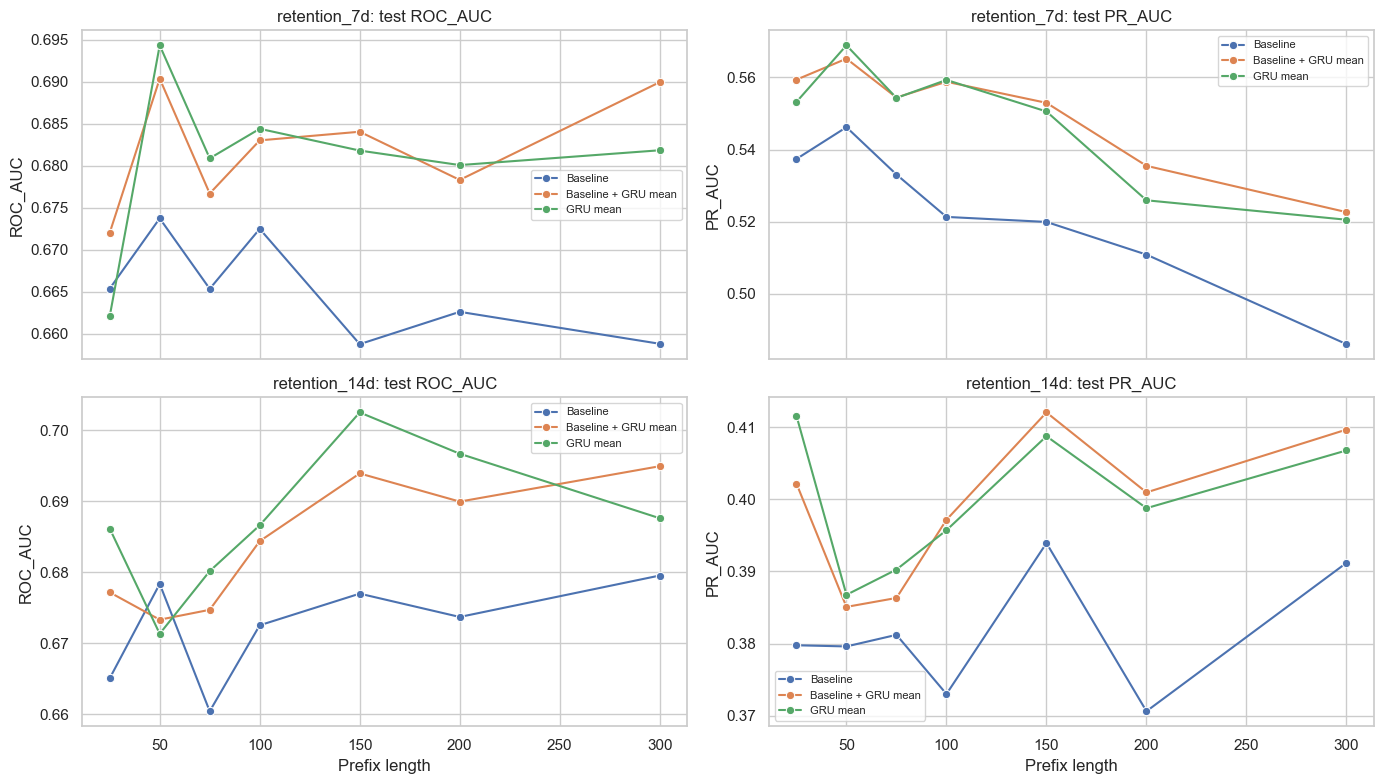

In [7]:
plot_pdf = to_pandas(test_metrics_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=False)
for row_idx, label_name in enumerate(['retention_7d', 'retention_14d']):
    label_subset = plot_pdf[plot_pdf['label'] == label_name]
    for col_idx, metric_name in enumerate(['roc_auc', 'pr_auc']):
        ax = axes[row_idx, col_idx]
        sns.lineplot(
            data=label_subset,
            x='prefix_len',
            y=metric_name,
            hue='feature_set',
            marker='o',
            dashes=False,
            ax=ax,
        )
        ax.set_title(f'{label_name}: test {metric_name.upper()}')
        ax.set_xlabel('Prefix length')
        ax.set_ylabel(metric_name.upper())
        ax.legend(fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'common_valid_prefix_metrics.png', dpi=180)
plt.show()


In [8]:
best_rows_df = (
    test_metrics_df
    .sort(['label', 'feature_set', 'roc_auc'], descending=[False, False, True])
    .group_by(['label', 'feature_set'], maintain_order=True)
    .first()
    .sort(['label', 'feature_set'])
)
best_rows_df.write_csv(OUT_DIR / 'common_valid_best_test_rows.csv')
best_rows_df


label,feature_set,prefix_len,split,roc_auc,pr_auc,num_users
str,str,i32,str,f64,f64,i64
"""retention_14d""","""Baseline""",300,"""test""",0.679541,0.391196,1824
"""retention_14d""","""Baseline + GRU mean""",300,"""test""",0.694955,0.409645,1824
"""retention_14d""","""GRU mean""",150,"""test""",0.702537,0.408724,1824
"""retention_7d""","""Baseline""",50,"""test""",0.673725,0.546182,2239
"""retention_7d""","""Baseline + GRU mean""",50,"""test""",0.690349,0.565163,2239
"""retention_7d""","""GRU mean""",50,"""test""",0.694318,0.568857,2239


Вывод.

Для комбинированного варианта `Baseline + GRU mean` лучшим по ROC-AUC оказывается `prefix_len=50` на `retention_7d` (`0.6903`) и `prefix_len=300` на `retention_14d` (`0.6950`), причём `150` почти не уступает на `14d` (`0.6939`). Поэтому `150` остаётся разумным рабочим компромиссом для сопоставимости с предыдущими ноутбуками, но эксперимент на общем множестве валидных пользователей показывает, что оптимальная длина не универсальна и не обязана расти монотонно.


## Итог

Common-valid ablation длины префикса отделил эффект длины префикса от эффекта изменения состава пользователей. В общей когорте осталось `2,239` test-пользователей для `retention_7d` и `1,824` test-пользователя для `retention_14d`. Это меньше, чем в обычном ablation длины префикса, зато все `prefix_len` сравниваются на одних и тех же пользователях.

Для `retention_7d` лучший результат среди RNN-вариантов достигается при `prefix_len=50`: чистый `GRU mean` даёт ROC-AUC `0.6943` и PR-AUC `0.5689`, а `Baseline + GRU mean` — ROC-AUC `0.6903` и PR-AUC `0.5652`. Tabular baseline слабее по ROC-AUC: лучший вариант у него тоже `prefix_len=50` с ROC-AUC `0.6737`. Значит, на фиксированной когорте RNN-эмбеддинг действительно добавляет сигнал к простым табличным признакам.

Для `retention_14d` картина похожая, но не монотонная. Лучший ROC-AUC у чистого `GRU mean` получается при `prefix_len=150` (`0.7025`), а у `Baseline + GRU mean` — при `prefix_len=300` (`0.6950`), хотя `150` почти рядом (`0.6939`) и имеет лучший PR-AUC в комбинированном варианте (`0.4120`). Это показывает, что больше истории не всегда лучше и что различия между соседними prefix lengths нужно трактовать осторожно.

Главный вывод: прежняя немонотонность ablation длины префикса не была только артефактом меняющегося состава пользователей. Даже на common-valid когорте графики остаются неровными: `50` событий лучше для `retention_7d`, `150` — для чистого `GRU mean` на `retention_14d`, а `300` иногда выигрывает в комбинации с baseline. Практический выбор `prefix_len=150` остаётся не как математический optimum, а как сильный и сопоставимый компромисс для основной линии экспериментов.